In [12]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import pickle as pkl
import torch
import numpy as np

In [46]:
protein_dict = pkl.load(open("protein_features.pkl", "rb"))
model = pkl.load(open("models/esm2_8M.pkl", "rb"))
tokenizer = pkl.load(open("models/esm2_8M_tokenizer.pkl", "rb"))
device = 'cpu'

In [47]:

embeddings = np.zeros(shape=[1000,320])
weights = []
pHs = []

In [48]:
i = 0
for key, value in protein_dict.items():
    if i == 1000:
        break
    sequence = value['sequence']
    inputs = tokenizer(sequence, return_tensors="pt").to(device)
    outputs = model(**inputs)
    embeddings[i] = outputs.last_hidden_state.detach().numpy().sum(axis=1).squeeze()
    analysis = ProteinAnalysis(sequence)
    protein_dict[key]['molecular_weight'] = analysis.molecular_weight()
    weights.append(analysis.molecular_weight())
    protein_dict[key]['isoelectric_point'] = analysis.isoelectric_point()
    pHs.append(analysis.isoelectric_point())
    i += 1

## Quick Regression Test to analyze info stored in embeds

In [62]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Prepare Data
# X should be shape (n_samples, 1280)
# y should be shape (n_samples,)
X = np.array(embeddings) 
y = np.array(weights)

# 2. Split into Training and Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.995, random_state=42)

# 3. Initialize and Train
# Use 'Ridge' instead of basic LinearRegression to handle high-dimensional 
# multicollinearity (it adds L2 regularization).
model = Ridge(alpha=1.0) 
model.fit(X_train, y_train)

# 4. Predict and Evaluate
y_pred = model.predict(X_test)

print(f"R^2 Score: {r2_score(y_test, y_pred):.3f}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.3f}")

R^2 Score: 0.947
Mean Squared Error: 161634319.752


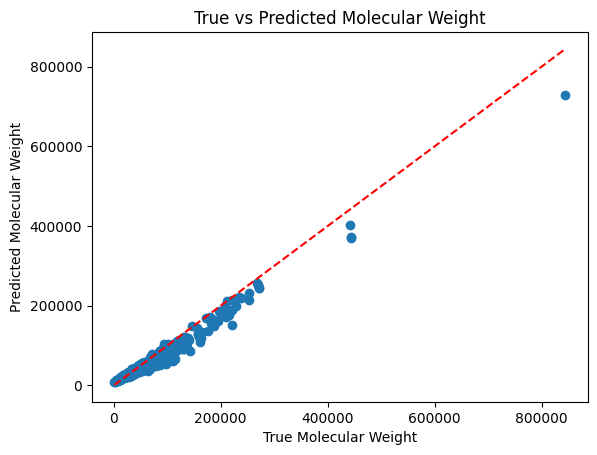

In [63]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred)
plt.xlabel("True Molecular Weight")
plt.ylabel("Predicted Molecular Weight")
plt.title("True vs Predicted Molecular Weight")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # Line for perfect predictions
plt.show()